In [7]:
import pandas as pd
import numpy as np
import sklearn
from sklearn.model_selection import train_test_split
import shap

shap.initjs()

In [8]:
# used for models with predict probabilities
def l_shap_predict_proba(model, instance_index):
    
    explainer = shap.KernelExplainer(model.predict_proba, X_train)
    shap_values = explainer.shap_values(X_test.iloc[0, :])  # Get SHAP values for the first sample
    
    shap.force_plot(explainer.expected_value[1], shap_values[:,1], X_test.iloc[0, :])  # Force plot for class 1
    explainer = shap.KernelExplainer(model.predict_proba, X_train)
    shap_values = explainer.shap_values(X_test)
    
    # Extract SHAP values for the selected instance and class (e.g., class 1)
    shap_values_instance_class_1 = shap_values[instance_index, :, 1]
    
    # Get the feature values for that instance
    feature_values = X_test.iloc[instance_index]
    
    # Plot the waterfall chart for the chosen instance and class
    shap.waterfall_plot(
        shap.Explanation(values=shap_values_instance_class_1,
                         base_values=explainer.expected_value[1],  # Base value for class 1
                         data=feature_values,
                         feature_names=X_test.columns)
    )

In [9]:
# used for binary models

def l_shap_binary(model, instance_index):

    def predict_with_names(X):
        X = pd.DataFrame(X, columns=X_train.columns)

        s = model.decision_function(X)  # (n_samples,) for binary
        p1 = 1 / (1 + np.exp(-s))          # sigmoid -> (0,1)
        p0 = 1 - p1
        return np.vstack([p0, p1]).T       # sums to 1

    explainer = shap.KernelExplainer(predict_with_names, X_train)
    shap_values = explainer.shap_values(X_test.iloc[0, :])  # Get SHAP values for the first sample

    shap.force_plot(explainer.expected_value[1], shap_values[:,1], X_test.iloc[0, :])  # Force plot for class 1
    explainer = shap.KernelExplainer(predict_with_names, X_train)
    shap_values = explainer.shap_values(X_test)

    # Extract SHAP values for the selected instance and class (e.g., class 1)
    shap_values_instance_class_1 = shap_values[instance_index, :, 1]

    # Get the feature values for that instance
    feature_values = X_test.iloc[instance_index]

    # Plot the waterfall chart for the chosen instance and class
    shap.waterfall_plot(
        shap.Explanation(values=shap_values_instance_class_1,
                         base_values=explainer.expected_value[1],  # Base value for class 1
                         data=feature_values,
                         feature_names=X_test.columns)
    )

__LIME for Base model - ALL Features (Decision Tree)__

In [10]:
df = pd.read_csv("b_all_ii.csv")
target = df["AgreeSubsequentBooster"]
features = df.drop("AgreeSubsequentBooster",axis=1)

features[["Location", "Race", "Religion"]] = (
    features[["Location", "Race", "Religion"]]
    .astype("category")
    .apply(lambda x: x.cat.codes)
)

# Split the dataset into training + development set and test set
X_train, X_test, Y_train, Y_test = train_test_split(features, target, test_size = 0.2, random_state = 0)

Using 159 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.
Using 159 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


  0%|          | 0/40 [00:00<?, ?it/s]

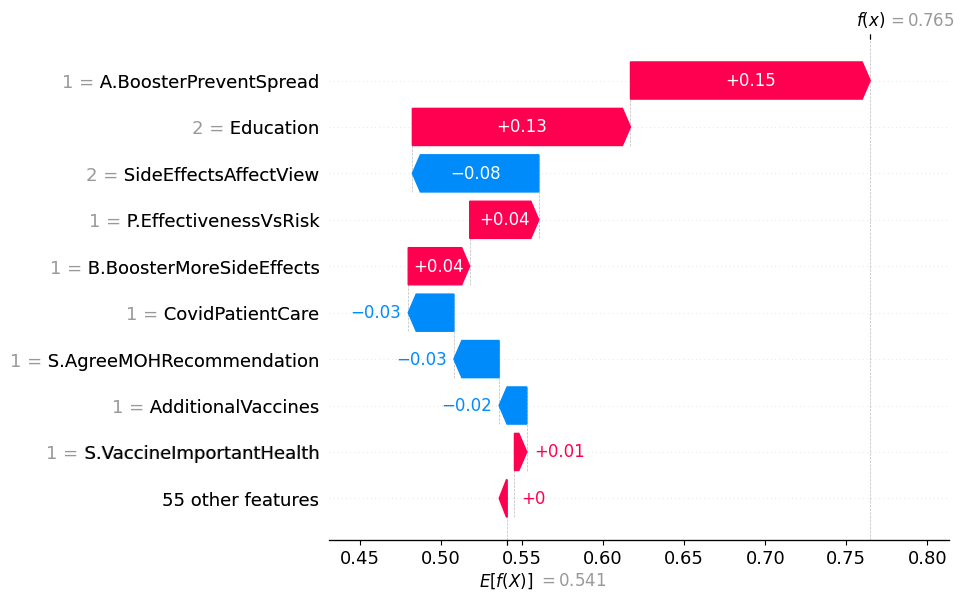

In [11]:
from sklearn.tree import DecisionTreeClassifier

# run the decision tree model

model_dt = DecisionTreeClassifier(max_depth=5, criterion='entropy', random_state=0)
model_dt.fit(X_train, Y_train)

l_shap_predict_proba(model=model_dt, instance_index=0)

__LIME for Base model - ALL Features (SVM rbf)__

Using 159 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.
Using 159 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


  0%|          | 0/40 [00:00<?, ?it/s]

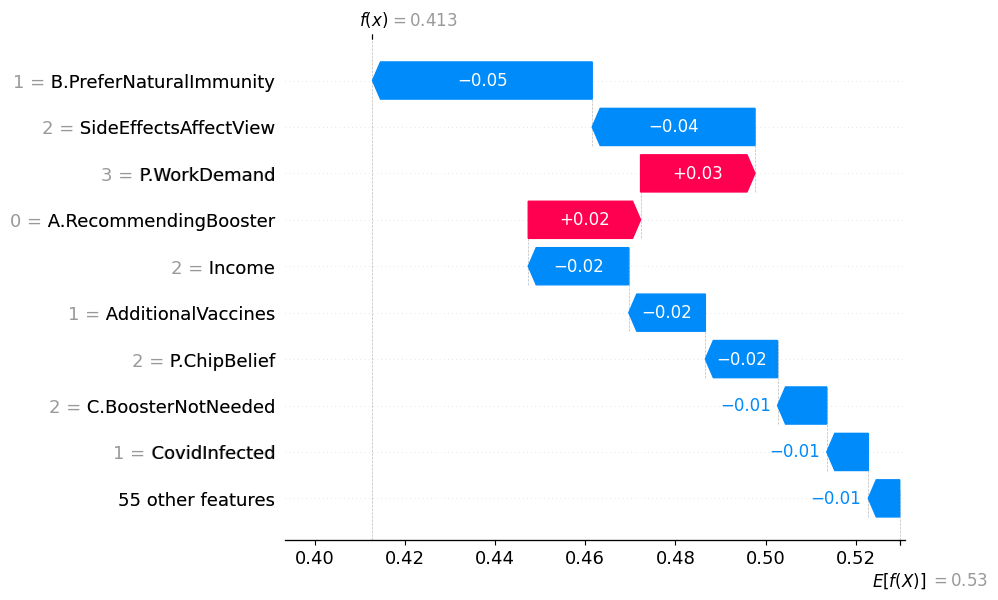

In [12]:
from sklearn.svm import SVC

# run the svm rbf model
model_svm_rbf = SVC(kernel="rbf", C= 1, gamma= "scale")
model_svm_rbf.fit(X_train, Y_train)

l_shap_binary(model=model_svm_rbf, instance_index=0)

__LIME for ALL Features with Anova + Chi Square (GNB)__

In [13]:
df = pd.read_csv("b_all_ac.csv")
target = df["AgreeSubsequentBooster"]
features = df.drop("AgreeSubsequentBooster",axis=1)

# Split the dataset into training + development set and test set
X_train, X_test, Y_train, Y_test = train_test_split(features, target, test_size = 0.2, random_state = 0)

In [14]:
from sklearn.naive_bayes import GaussianNB

# encoder not needed because race, religion and location is not in booster anova chi dataset

model_gnb = GaussianNB()
model_gnb.fit(X_train, Y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


Using 159 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.
Using 159 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


  0%|          | 0/40 [00:00<?, ?it/s]

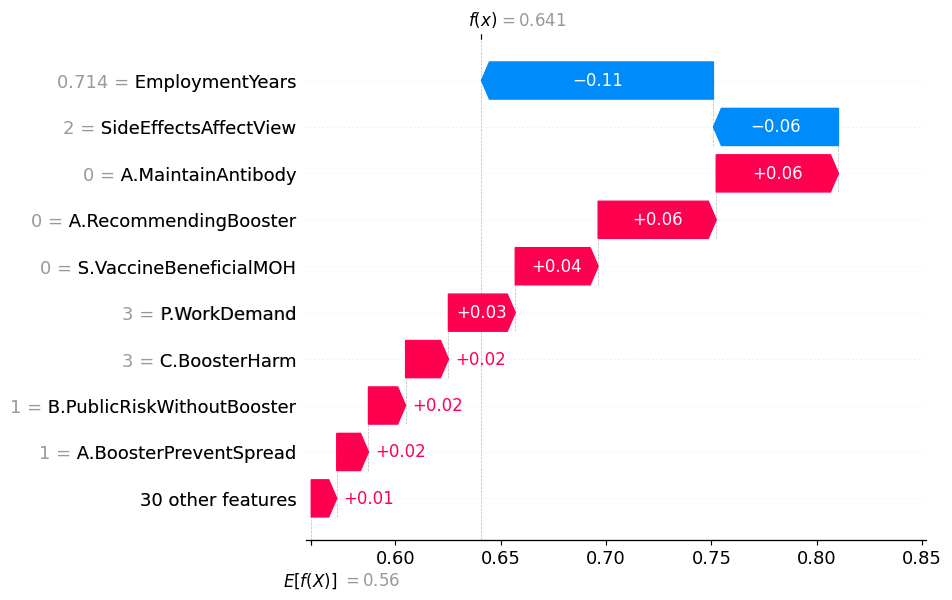

In [15]:
l_shap_predict_proba(model=model_gnb, instance_index=0)

__LIME for Base model - Aggregated (Bagging - SVM poly)__

Using 159 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.
Using 159 background data samples could cause slower run times. Consider using shap.sample(data, K) or shap.kmeans(data, K) to summarize the background as K samples.


  0%|          | 0/40 [00:00<?, ?it/s]

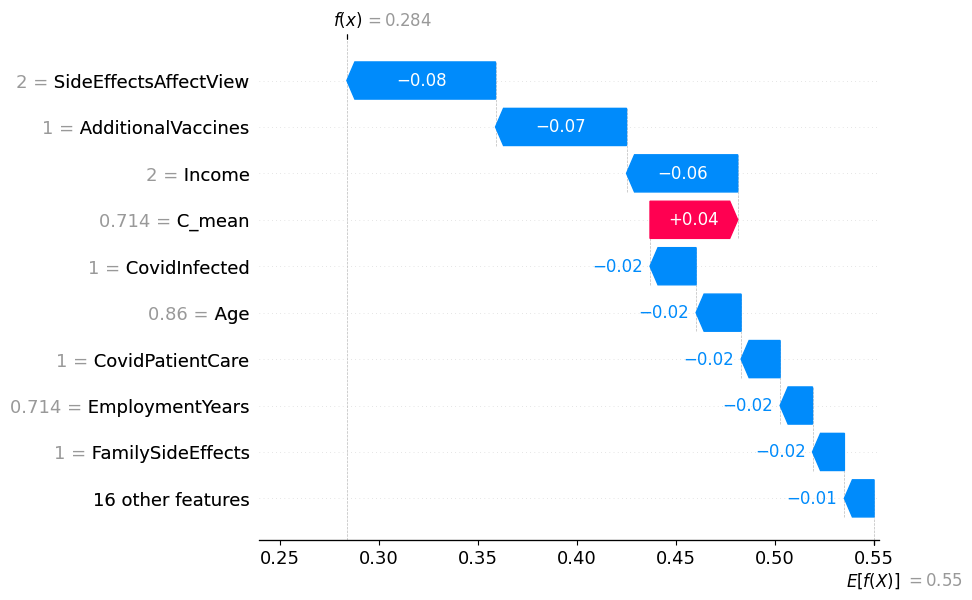

In [17]:
df = pd.read_csv("b_avg_all_ii.csv")
target = df["AgreeSubsequentBooster"]
features = df.drop("AgreeSubsequentBooster", axis=1)

features[["Location", "Race", "Religion"]] = (
    features[["Location", "Race", "Religion"]]
    .astype("category")
    .apply(lambda x: x.cat.codes)
)

# Split the dataset into training + development set and test set
X_train, X_test, Y_train, Y_test = train_test_split(
    features, target, test_size=0.2, random_state=0
)

from sklearn.svm import SVC
from sklearn.ensemble import BaggingClassifier

# base model: SVM poly
base_svm_poly = SVC(
    C=1,
    kernel='poly',
    degree=2,
    gamma='scale',
    probability=True,
    random_state=0
)

# bagging with SVM poly
model_bagging_svm_poly = BaggingClassifier(
    estimator=base_svm_poly,
    n_estimators=10,
    random_state=0
)

model_bagging_svm_poly.fit(X_train, Y_train)

# Choose an instance from the test set
instance_to_explain = X_test.iloc[0].values  # Convert to NumPy array

l_shap_predict_proba(model_bagging_svm_poly, 0)

__LIME for Aggregated Features with Anova + Chi Square (Boosting)__

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

df = pd.read_csv("b_avg_ac.csv")
target = df["AgreeSubsequentBooster"]
features = df.drop("AgreeSubsequentBooster",axis=1)

# encoder is not needed because race, religion and location is not in dataset for aggregated anova chi

# Split the dataset into training + development set and test set
X_train, X_test, Y_train, Y_test = train_test_split(features, target, test_size = 0.2, random_state = 0)

model_boosting_ac = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
model_boosting_ac.fit(X_train, Y_train)

In [ ]:
l_shap_binary(model=model_boosting_ac, instance_index=0)

__LIME for Aggregated Features with Anova + Chi Square (GNB)__

In [ ]:
model_gnb_ac = GaussianNB()
model_gnb_ac.fit(X_train, Y_train)

In [ ]:
l_shap_predict_proba(model=model_gnb_ac, instance_index=0)